In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/fedesoriano/stellar-classification-dataset-sdss17/star_classification.csv


# 🔭 Stellar Classification — Support Vector Machine (SVM)

## Problem Statement
Classify celestial objects observed by the **Sloan Digital Sky Survey (SDSS)**  
into one of three categories:
- ⭐ **Star** — a luminous point of light
- 🌌 **Galaxy** — a system of millions of stars
- ⚡ **QSO** — Quasi-Stellar Object (Quasar) — extremely energetic galaxy cores

This is a **multi-class classification** problem with high-dimensional spectroscopic data.

## Dataset
- **Source:** [Kaggle — Stellar Classification SDSS17](https://www.kaggle.com/datasets/fedesoriano/stellar-classification-dataset-sdss17)
- **Rows:** 100,000 observations
- **Features:** 17 (spectroscopic + photometric measurements)
- **Target:** `class` → STAR / GALAXY / QSO

## Why SVM?
| Algorithm | Decision Boundary |
|-----------|------------------|
| Logistic Regression | Linear hyperplane |
| Random Forest | Axis-aligned splits |
| **SVM** | **Maximum margin hyperplane** — finds the boundary that maximizes distance from nearest points of each class |

SVM excels when:
- Classes are **well-separated** in feature space
- Data is **high-dimensional** (spectroscopic data fits perfectly)
- You need a **strong geometric intuition** about boundaries

## New Concepts This Notebook
1. **Kernel Trick** — projects data to higher dimensions to find non-linear boundaries
2. **Support Vectors** — only the boundary points matter, not all data
3. **Calibrated probabilities** — SVM doesn't give probabilities natively
4. **OvR strategy** — how SVM handles multi-class problems
5. **Cohen's Kappa** — evaluation metric beyond accuracy for multi-class

## Notebook Roadmap
1. Imports & Data Loading
2. EDA — spectroscopic feature analysis
3. Preprocessing
4. SVM Baseline
5. Evaluation (multi-class metrics, confusion matrix)
6. Kernel comparison
7. Hyperparameter Tuning
8. Final Results & Key Learnings

In [4]:

# ============================================================
# STELLAR CLASSIFICATION — SUPPORT VECTOR MACHINE
# Dataset: SDSS17 Stellar Classification — Kaggle
# Goal: Classify objects as STAR / GALAXY / QSO (3-class)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC
from sklearn.model_selection import (train_test_split, RandomizedSearchCV,
                                     StratifiedKFold, cross_val_score)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score,
                             cohen_kappa_score, ConfusionMatrixDisplay)
from sklearn.calibration import CalibratedClassifierCV
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 5)

# --- Load Data ---
df = pd.read_csv('/kaggle/input/datasets/fedesoriano/stellar-classification-dataset-sdss17/star_classification.csv')

print("Shape:", df.shape)
print("\n Target Distribution:")
print(df['class'].value_counts())
print(df['class'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')
print("\n Columns:", df.columns.tolist())
display(df.head())


Shape: (100000, 18)

 Target Distribution:
class
GALAXY    59445
STAR      21594
QSO       18961
Name: count, dtype: int64
class
GALAXY    59.44%
STAR      21.59%
QSO       18.96%
Name: proportion, dtype: object

 Columns: ['obj_ID', 'alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'run_ID', 'rerun_ID', 'cam_col', 'field_ID', 'spec_obj_ID', 'class', 'redshift', 'plate', 'MJD', 'fiber_ID']


,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842


## 2. Exploratory Data Analysis

### What makes this dataset unique?
Unlike tabular business data, these are **astronomical measurements**:
- `u, g, r, i, z` → brightness measured through 5 color filters (ultraviolet to infrared)
- `redshift` → how much light is stretched due to object moving away — **directly relates to distance**
- `alpha, delta` → right ascension & declination (sky coordinates)

### EDA Strategy here is different:
Instead of boxplots, we'll use:
- **Violin plots** → show full distribution shape, not just quartiles
- **Pair plot on key features** → see how classes separate in 2D feature space
- **Redshift distribution** → the single most powerful feature for this problem

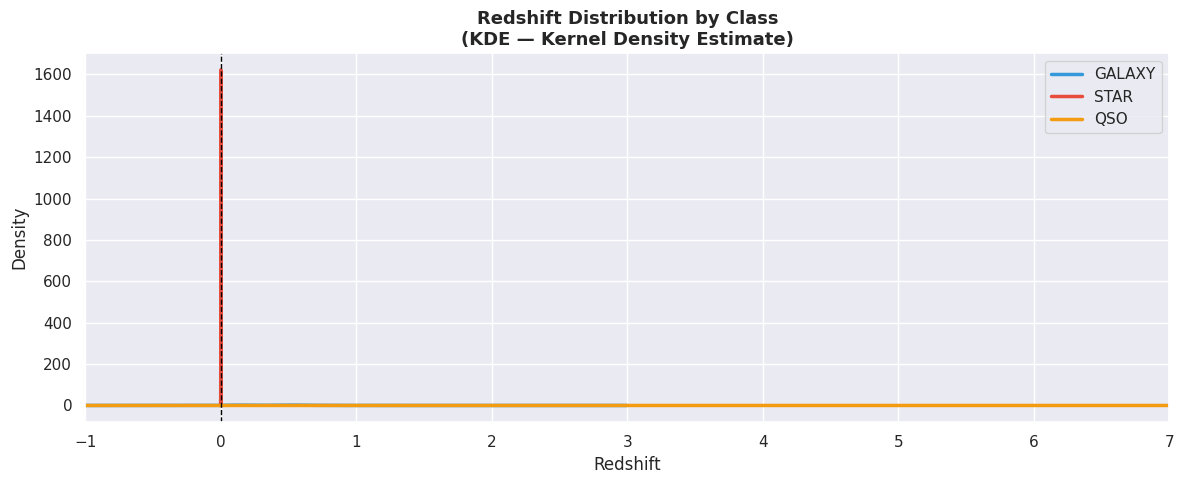

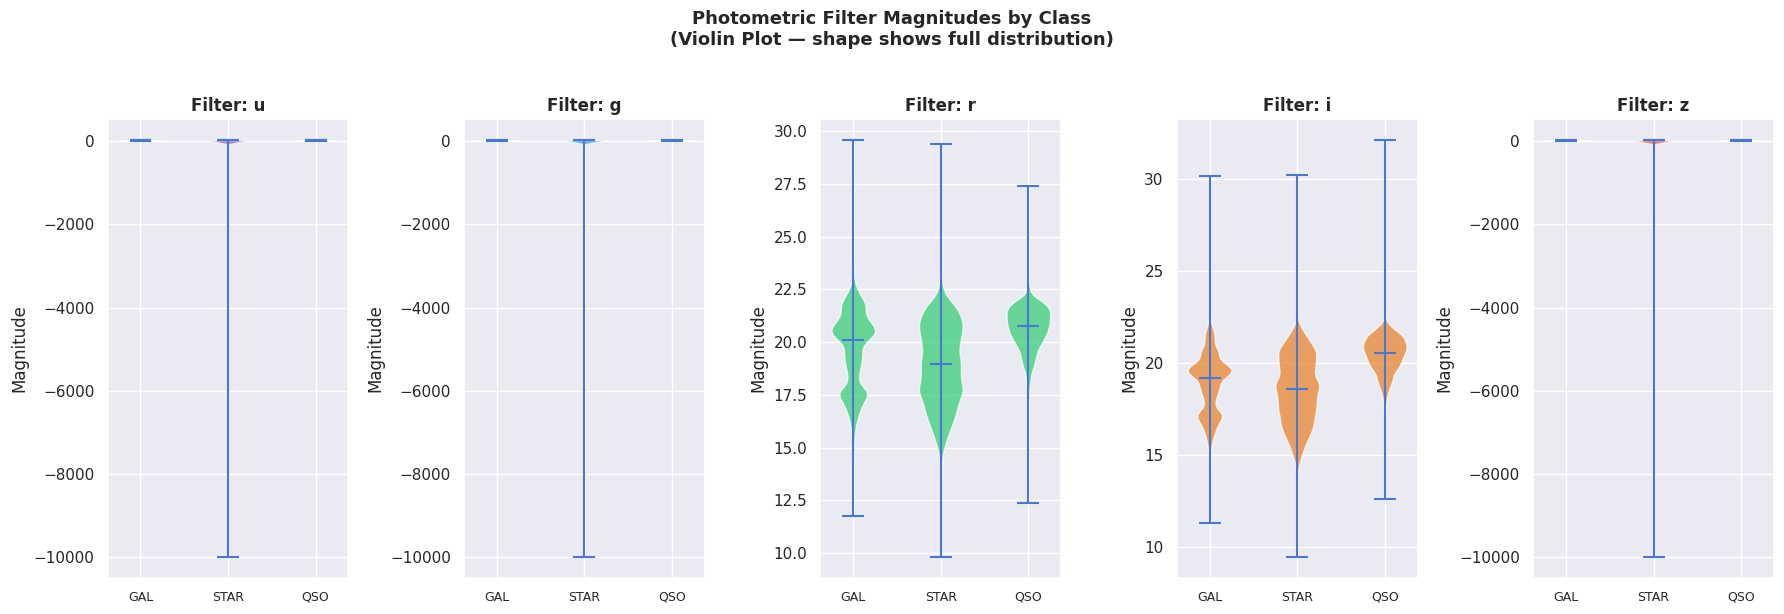

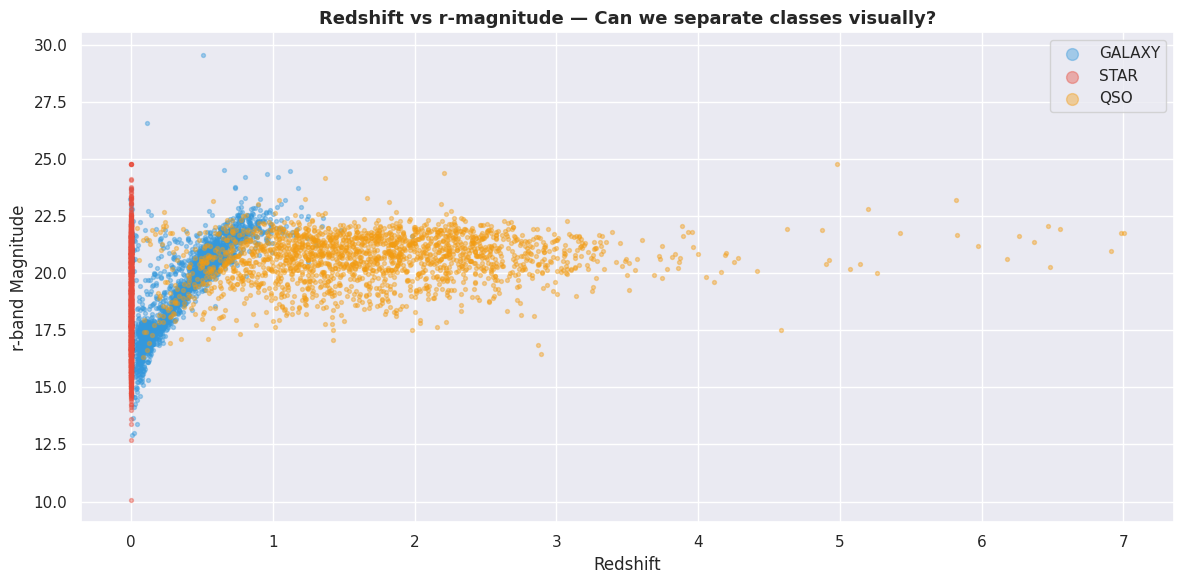

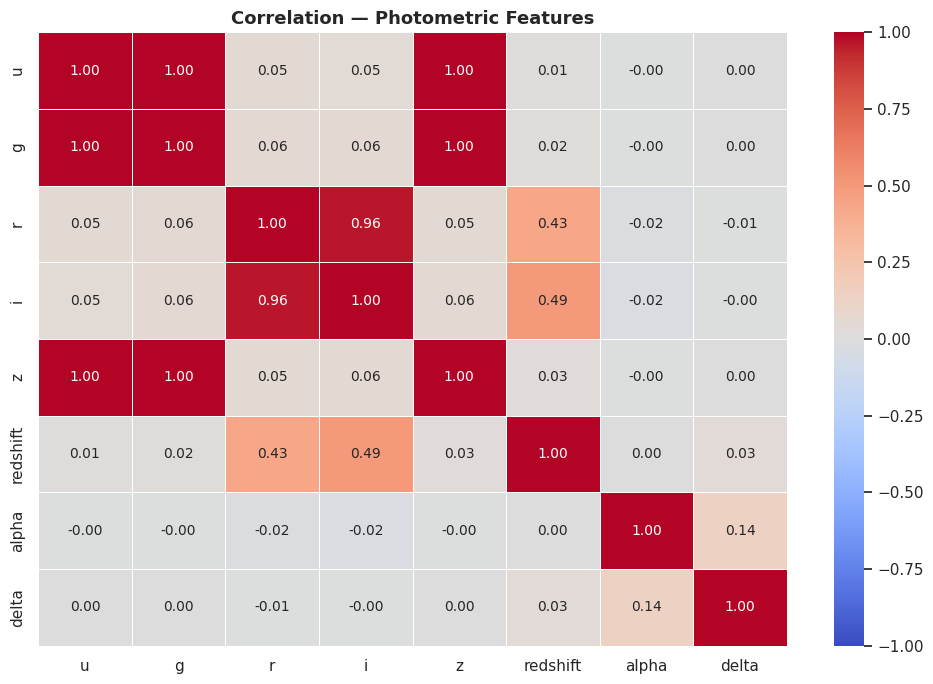

EDA complete!


In [5]:
# ============================================================
# CELL 2 — EDA: Stellar Classification
# New viz: Violin plots + Redshift KDE + 2D scatter separation
# ============================================================

# --- 1. Redshift distribution by class (KDE plot — new!) ---
# KDE = Kernel Density Estimate: smooth histogram showing probability density
plt.figure(figsize=(12, 5))
for cls, color in zip(['GALAXY', 'STAR', 'QSO'], ['#3498db', '#e74c3c', '#f39c12']):
    subset = df[df['class'] == cls]['redshift']
    subset.plot.kde(label=cls, color=color, linewidth=2.5)

plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.title('Redshift Distribution by Class\n'
          '(KDE — Kernel Density Estimate)', fontsize=13, fontweight='bold')
plt.xlabel('Redshift')
plt.ylabel('Density')
plt.xlim(-1, 7)
plt.legend()
plt.tight_layout()
plt.show()

# --- 2. Violin plots for photometric filters ---
# Violin = boxplot + KDE shape — shows bimodality, skewness better
fig, axes = plt.subplots(1, 5, figsize=(18, 6), sharey=False)
filters = ['u', 'g', 'r', 'i', 'z']
colors  = ['#9b59b6', '#3498db', '#2ecc71', '#e67e22', '#e74c3c']

for ax, filt, col in zip(axes, filters, colors):
    data_list = [df[df['class'] == cls][filt].dropna() for cls in ['GALAXY', 'STAR', 'QSO']]
    parts = ax.violinplot(data_list, positions=[1, 2, 3], showmedians=True)
    for pc, c in zip(parts['bodies'], [col]*3):
        pc.set_facecolor(c)
        pc.set_alpha(0.7)
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(['GAL', 'STAR', 'QSO'], fontsize=9)
    ax.set_title(f'Filter: {filt}', fontweight='bold')
    ax.set_ylabel('Magnitude')

plt.suptitle('Photometric Filter Magnitudes by Class\n'
             '(Violin Plot — shape shows full distribution)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# --- 3. 2D Scatter: Redshift vs r-filter (do classes separate?) ---
plt.figure(figsize=(12, 6))
colors_map = {'GALAXY': '#3498db', 'STAR': '#e74c3c', 'QSO': '#f39c12'}
for cls, col in colors_map.items():
    subset = df[df['class'] == cls].sample(2000, random_state=42)
    plt.scatter(subset['redshift'], subset['r'], 
                c=col, label=cls, alpha=0.4, s=8)

plt.xlabel('Redshift', fontsize=12)
plt.ylabel('r-band Magnitude', fontsize=12)
plt.title('Redshift vs r-magnitude — Can we separate classes visually?',
          fontsize=13, fontweight='bold')
plt.legend(markerscale=3)
plt.tight_layout()
plt.show()

# --- 4. Correlation heatmap — do filters correlate with each other? ---
plt.figure(figsize=(10, 7))
key_cols = ['u', 'g', 'r', 'i', 'z', 'redshift', 'alpha', 'delta']
corr = df[key_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1,
            annot_kws={'size': 10})
plt.title('Correlation — Photometric Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("EDA complete!")

## 3. Preprocessing

### What the EDA told us — and how we respond:

| Observation | Action |
|-------------|--------|
| `obj_ID`, `run_ID`, `rerun_ID`, `cam_col`, `field_ID`, `spec_obj_ID`, `plate`, `MJD`, `fiber_ID` | Drop — telescope metadata, zero signal |
| `u`, `g`, `z` filters showing -9999 values | These are **sentinel missing values** in astronomy — clip to valid range |
| `r` and `i` correlation = 0.96 | Keep both — SVM handles multicollinearity better than LR |
| `redshift` spikes at 0 for STAR | This is real signal — keep as-is |
| Target is string (STAR/GALAXY/QSO) | Label encode to 0/1/2 |

### New concept: Sentinel Missing Values
In scientific datasets, missing values are often encoded as `-9999` or `-999`  
rather than `NaN`. Always check `df.describe()` min values!

### Why StandardScaler is CRITICAL for SVM?
SVM finds the maximum margin hyperplane — this is directly affected by feature scale.  
A feature with range [0, 10000] will completely dominate one with range [0, 1].  
**SVM is the most scale-sensitive algorithm we've seen so far.**

In [6]:
# ============================================================
# CELL 3 — Preprocessing
# New concept: sentinel value detection + clipping
# ============================================================

# --- Step 1: Check for sentinel missing values (-9999 style) ---
print("📊 Min values per column (checking for sentinel -9999):")
print(df.describe().loc['min'].sort_values().head(10))

# --- Step 2: Drop telescope metadata columns ---
drop_cols = ['obj_ID', 'run_ID', 'rerun_ID', 'cam_col', 
             'field_ID', 'spec_obj_ID', 'plate', 'MJD', 'fiber_ID']
df_clean = df.drop(columns=drop_cols)
print(f"\nAfter dropping metadata: {df_clean.shape}")

# --- Step 3: Clip sentinel values in photometric filters ---
# Valid astronomical magnitude range: roughly 0 to 35
# Values like -9999 are SDSS's way of saying "measurement failed"
filter_cols = ['u', 'g', 'r', 'i', 'z']
for col in filter_cols:
    n_bad = (df_clean[col] < 0).sum()
    if n_bad > 0:
        print(f"  {col}: {n_bad} sentinel values clipped")
    df_clean[col] = df_clean[col].clip(lower=0, upper=35)

# --- Step 4: Encode target ---
le = LabelEncoder()
df_clean['class_encoded'] = le.fit_transform(df_clean['class'])
print(f"\nClass mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# --- Step 5: Feature engineering — color indices ---
# New concept: domain-driven feature engineering
# In astronomy, COLOR = difference between two filter magnitudes
# Color indices capture spectral shape — powerful discriminators
df_clean['u_g'] = df_clean['u'] - df_clean['g']   # UV vs optical
df_clean['g_r'] = df_clean['g'] - df_clean['r']   # Blue vs red
df_clean['r_i'] = df_clean['r'] - df_clean['i']   # Red vs infrared
df_clean['i_z'] = df_clean['i'] - df_clean['z']   # Near-infrared

print(f"\nAfter feature engineering: {df_clean.shape}")
print("Color indices added: u_g, g_r, r_i, i_z ✅")

# --- Step 6: Split ---
X = df_clean.drop(columns=['class', 'class_encoded'])
y = df_clean['class_encoded']

# SVM is slow on 100k rows — sample 30k stratified for speed
# (still large enough for robust results)
from sklearn.utils import resample
X_sample, y_sample = resample(X, y, n_samples=30000, 
                               random_state=42, stratify=y)
print(f"\nSampled for SVM speed: {X_sample.shape}")
print(f"Class distribution preserved:\n{pd.Series(y_sample).value_counts()}")

X_train, X_test, y_train, y_test = train_test_split(
    X_sample, y_sample, test_size=0.2, random_state=42, stratify=y_sample)

# --- Step 7: Scale (CRITICAL for SVM) ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"\nTrain: {X_train_scaled.shape} | Test: {X_test_scaled.shape}")
print("Preprocessing complete!")


📊 Min values per column (checking for sentinel -9999):
u          -9999.000000
g          -9999.000000
z          -9999.000000
delta        -18.785328
redshift      -0.009971
alpha          0.005528
cam_col        1.000000
fiber_ID       1.000000
i              9.469903
r              9.822070
Name: min, dtype: float64

After dropping metadata: (100000, 9)
  u: 1 sentinel values clipped
  g: 1 sentinel values clipped
  z: 1 sentinel values clipped

Class mapping: {'GALAXY': np.int64(0), 'QSO': np.int64(1), 'STAR': np.int64(2)}

After feature engineering: (100000, 14)
Color indices added: u_g, g_r, r_i, i_z ✅

Sampled for SVM speed: (30000, 12)
Class distribution preserved:
class_encoded
0    17834
2     6478
1     5688
Name: count, dtype: int64

Train: (24000, 12) | Test: (6000, 12)
Preprocessing complete!


## 4. SVM — Baseline + Kernel Comparison

### The Kernel Trick — Core SVM Concept

SVM finds a hyperplane that **maximally separates** classes.  
But what if data isn't linearly separable in 2D?

**Kernel trick:** mathematically projects data into higher dimensions  
where a linear boundary CAN separate classes — without actually computing  
the high-dimensional coordinates (computationally elegant!).

| Kernel | What it does | Best for |
|--------|-------------|----------|
| `linear` | Straight hyperplane | Already separable data |
| `rbf` | Gaussian radial basis — circular boundaries | Most real-world data |
| `poly` | Polynomial curves | Data with polynomial relationships |

### Multi-class Strategy: One-vs-Rest (OvR)
SVM is natively binary. For 3 classes (GALAXY, QSO, STAR):  
- Classifier 1: GALAXY vs (QSO + STAR)  
- Classifier 2: QSO vs (GALAXY + STAR)  
- Classifier 3: STAR vs (GALAXY + QSO)  
Final prediction = class with highest confidence score.

### New evaluation metric: Cohen's Kappa
Accuracy can be misleading when classes are imbalanced.  
**Cohen's Kappa** measures agreement between predictions and truth,  
**correcting for chance agreement.**  
- κ = 1.0 → perfect  
- κ = 0.0 → no better than random  
- κ < 0 → worse than

 Comparing SVM Kernels...

  Kernel: linear   | Accuracy: 0.9443 | Kappa: 0.9030
  Kernel: rbf      | Accuracy: 0.9493 | Kappa: 0.9114
  Kernel: poly     | Accuracy: 0.9292 | Kappa: 0.8755

 Best kernel: rbf

    SVM (RBF KERNEL) — DETAILED RESULTS
              precision    recall  f1-score   support

      GALAXY       0.98      0.94      0.96      3567
         QSO       0.94      0.93      0.93      1138
        STAR       0.89      0.99      0.94      1295

    accuracy                           0.95      6000
   macro avg       0.94      0.95      0.94      6000
weighted avg       0.95      0.95      0.95      6000



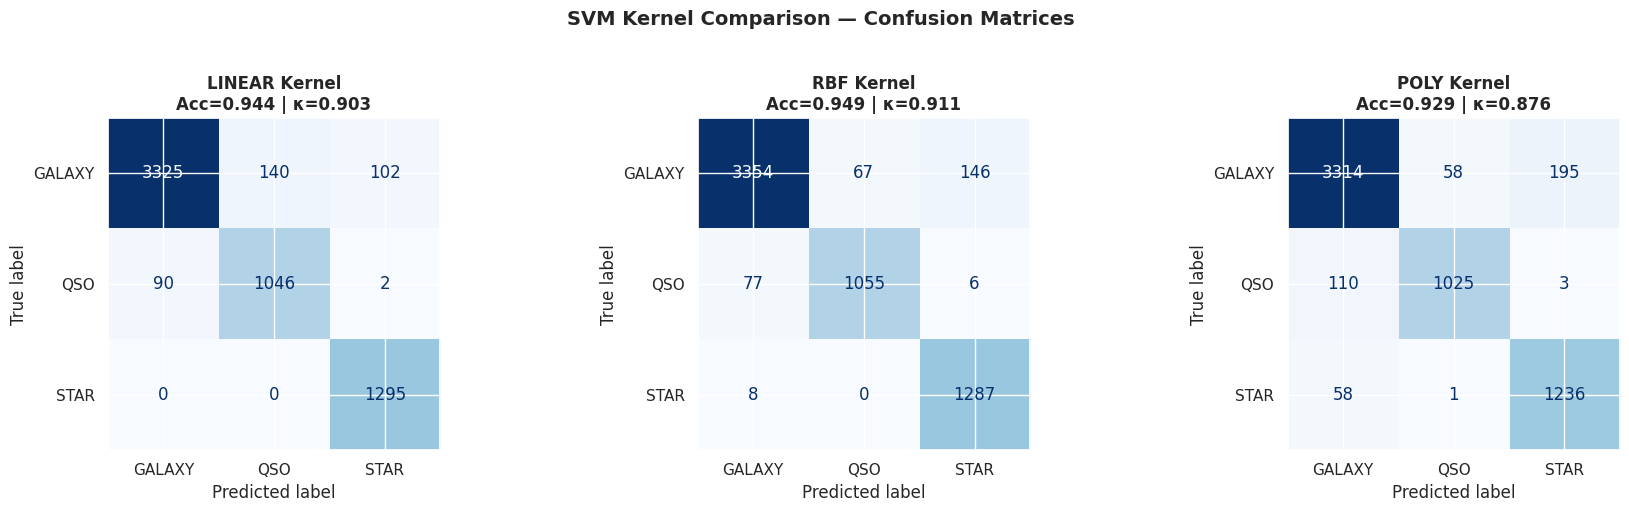

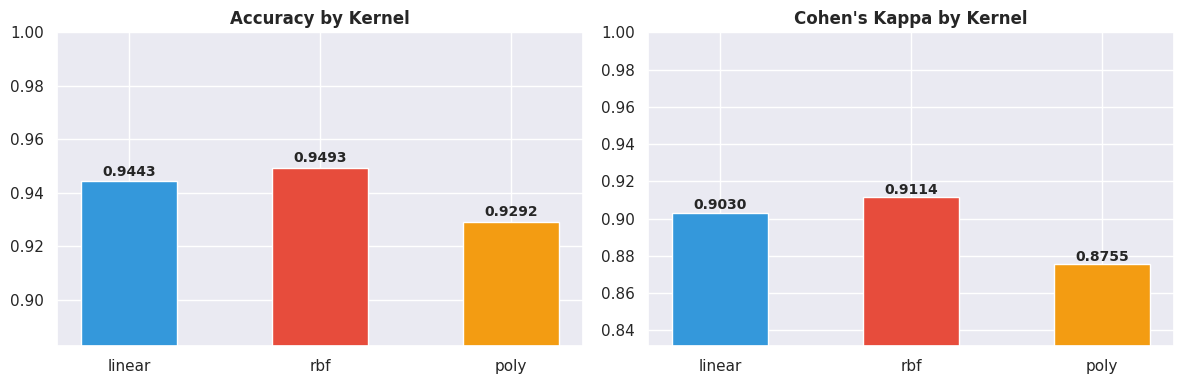

Kernel comparison complete!


In [7]:
# ============================================================
# CELL 4 — SVM: Kernel Comparison
# New concept: comparing kernels, Cohen's Kappa, OvR multiclass
# ============================================================

from sklearn.metrics import cohen_kappa_score, ConfusionMatrixDisplay

kernels = ['linear', 'rbf', 'poly']
kernel_results = {}

print(" Comparing SVM Kernels...\n")
for kernel in kernels:
    svm = SVC(kernel=kernel, decision_function_shape='ovr',
              class_weight='balanced', random_state=42)
    svm.fit(X_train_scaled, y_train)
    y_pred_k = svm.predict(X_test_scaled)
    
    acc   = (y_pred_k == y_test).mean()
    kappa = cohen_kappa_score(y_test, y_pred_k)
    kernel_results[kernel] = {'accuracy': acc, 'kappa': kappa, 
                               'preds': y_pred_k, 'model': svm}
    print(f"  Kernel: {kernel:<8} | Accuracy: {acc:.4f} | Kappa: {kappa:.4f}")

# --- Pick best kernel ---
best_kernel = max(kernel_results, key=lambda k: kernel_results[k]['kappa'])
print(f"\n Best kernel: {best_kernel}")

best_svm    = kernel_results[best_kernel]['model']
y_pred_best = kernel_results[best_kernel]['preds']

# --- Full classification report for best kernel ---
print("\n" + "=" * 55)
print(f"    SVM ({best_kernel.upper()} KERNEL) — DETAILED RESULTS")
print("=" * 55)
class_names = ['GALAXY', 'QSO', 'STAR']
print(classification_report(y_test, y_pred_best, target_names=class_names))

# --- Confusion Matrix ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, kernel in zip(axes, kernels):
    cm = confusion_matrix(y_test, kernel_results[kernel]['preds'])
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
        ax=ax, colorbar=False, cmap='Blues')
    acc   = kernel_results[kernel]['accuracy']
    kappa = kernel_results[kernel]['kappa']
    ax.set_title(f'{kernel.upper()} Kernel\nAcc={acc:.3f} | κ={kappa:.3f}',
                 fontweight='bold')

plt.suptitle('SVM Kernel Comparison — Confusion Matrices', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# --- Kernel performance bar chart ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
metrics = ['accuracy', 'kappa']
titles  = ['Accuracy by Kernel', "Cohen's Kappa by Kernel"]
colors  = ['#3498db', '#e74c3c', '#f39c12']

for ax, metric, title in zip(axes, metrics, titles):
    vals = [kernel_results[k][metric] for k in kernels]
    bars = ax.bar(kernels, vals, color=colors, edgecolor='white', width=0.5)
    ax.set_title(title, fontweight='bold')
    ax.set_ylim(min(vals)*0.95, 1.0)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


print("Kernel comparison complete!")

In [ ]:
## 5. Hyperparameter Tuning — SVM (RBF Kernel)

### RBF Kernel Parameters:

| Parameter | What it controls | Effect |
|-----------|-----------------|--------|
| `C` | Regularization — penalty for misclassification | High C = less margin, fits training data harder |
| `gamma` | How far influence of a single training point reaches | High γ = tight fit, risk of overfit |

### C vs gamma — the classic SVM tradeoff:

🔬 Tuning C and Gamma for RBF kernel...

  C=0.1   gamma=scale    → CV Acc: 0.9302
  C=0.1   gamma=auto     → CV Acc: 0.9302
  C=0.1   gamma=0.01     → CV Acc: 0.8345
  C=0.1   gamma=0.001    → CV Acc: 0.7291
  C=1     gamma=scale    → CV Acc: 0.9561
  C=1     gamma=auto     → CV Acc: 0.9561
  C=1     gamma=0.01     → CV Acc: 0.9311
  C=1     gamma=0.001    → CV Acc: 0.7983
  C=10    gamma=scale    → CV Acc: 0.9641
  C=10    gamma=auto     → CV Acc: 0.9640
  C=10    gamma=0.01     → CV Acc: 0.9567
  C=10    gamma=0.001    → CV Acc: 0.8821
  C=100   gamma=scale    → CV Acc: 0.9659
  C=100   gamma=auto     → CV Acc: 0.9659
  C=100   gamma=0.01     → CV Acc: 0.9644
  C=100   gamma=0.001    → CV Acc: 0.9493


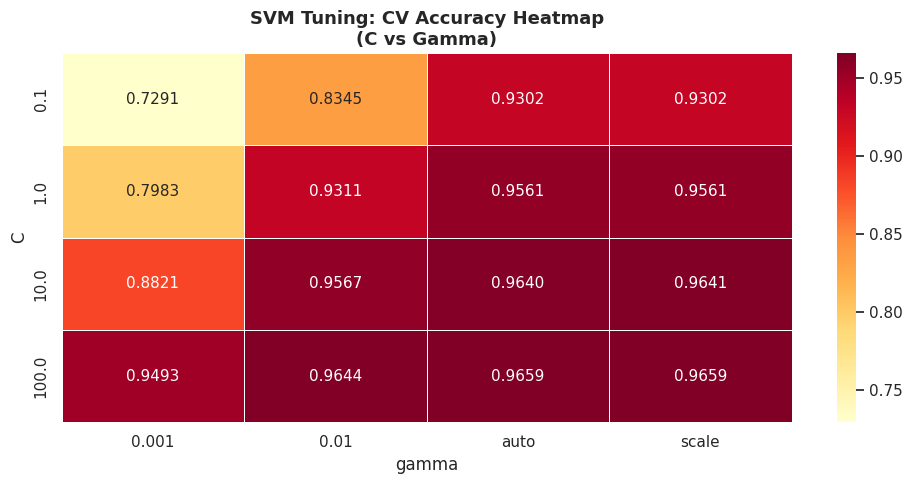


🏆 Best: C=100.0, gamma=scale, CV Acc=0.9659

        SVM TUNED — FINAL RESULTS
              precision    recall  f1-score   support

      GALAXY       0.98      0.96      0.97      3567
         QSO       0.94      0.93      0.94      1138
        STAR       0.95      1.00      0.97      1295

    accuracy                           0.96      6000
   macro avg       0.96      0.96      0.96      6000
weighted avg       0.97      0.96      0.96      6000

Cohen's Kappa: 0.9380


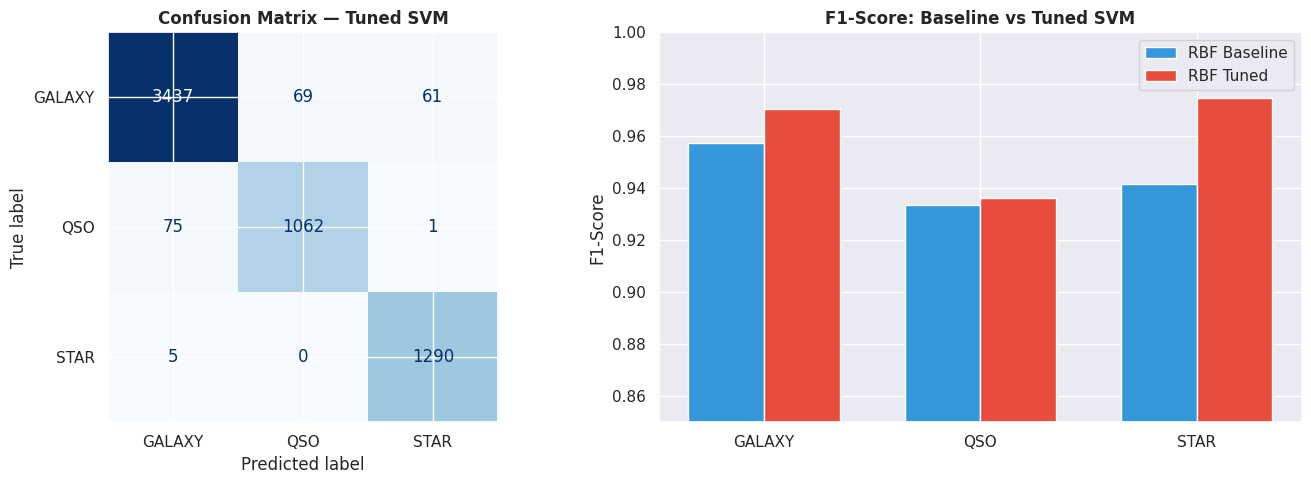

In [8]:
# ============================================================
# CELL 5 — SVM Tuning: C and Gamma + Final Evaluation
# New concept: manual focused search + decision boundary intuition
# ============================================================

from sklearn.metrics import cohen_kappa_score

# --- Focused parameter search around RBF sweet spot ---
param_grid = {
    'C'    : [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.001]
}

print("🔬 Tuning C and Gamma for RBF kernel...\n")
results_tune = []

for C in param_grid['C']:
    for gamma in param_grid['gamma']:
        svm = SVC(kernel='rbf', C=C, gamma=gamma,
                  class_weight='balanced', random_state=42)
        # 3-fold CV score (faster than 5-fold)
        cv_score = cross_val_score(
            svm, X_train_scaled, y_train,
            cv=3, scoring='accuracy', n_jobs=-1).mean()
        results_tune.append({'C': C, 'gamma': str(gamma), 
                             'cv_accuracy': cv_score})
        print(f"  C={str(C):<5} gamma={str(gamma):<8} → CV Acc: {cv_score:.4f}")

# --- Results heatmap (new viz: parameter sensitivity map) ---
results_df = pd.DataFrame(results_tune)
pivot = results_df.pivot(index='C', columns='gamma', values='cv_accuracy')

plt.figure(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlOrRd',
            linewidths=0.5, annot_kws={'size': 11})
plt.title('SVM Tuning: CV Accuracy Heatmap\n(C vs Gamma)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# --- Train best model ---
best_row   = results_df.loc[results_df['cv_accuracy'].idxmax()]
best_C     = best_row['C']
best_gamma = best_row['gamma']
print(f"\n🏆 Best: C={best_C}, gamma={best_gamma}, CV Acc={best_row['cv_accuracy']:.4f}")

# Convert gamma back if it's a string
gamma_val = best_gamma if best_gamma in ['scale', 'auto'] else float(best_gamma)

svm_final = SVC(kernel='rbf', C=best_C, gamma=gamma_val,
                class_weight='balanced', random_state=42)
svm_final.fit(X_train_scaled, y_train)
y_pred_final = svm_final.predict(X_test_scaled)

print("\n" + "=" * 55)
print("        SVM TUNED — FINAL RESULTS")
print("=" * 55)
print(classification_report(y_test, y_pred_final,
                             target_names=['GALAXY', 'QSO', 'STAR']))
print(f"Cohen's Kappa: {cohen_kappa_score(y_test, y_pred_final):.4f}")

# --- Final confusion matrix ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred_final)
ConfusionMatrixDisplay(cm, display_labels=['GALAXY','QSO','STAR']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix — Tuned SVM', fontweight='bold')

# --- Per-class F1 comparison: baseline vs tuned ---
report_base  = classification_report(y_test, y_pred_best,
                                      target_names=['GALAXY','QSO','STAR'],
                                      output_dict=True)
report_tuned = classification_report(y_test, y_pred_final,
                                      target_names=['GALAXY','QSO','STAR'],
                                      output_dict=True)

classes   = ['GALAXY', 'QSO', 'STAR']
f1_base   = [report_base[c]['f1-score']  for c in classes]
f1_tuned  = [report_tuned[c]['f1-score'] for c in classes]
x         = np.arange(len(classes))
width     = 0.35

axes[1].bar(x - width/2, f1_base,  width, label='RBF Baseline',
            color='#3498db', edgecolor='white')
axes[1].bar(x + width/2, f1_tuned, width, label='RBF Tuned',
            color='#e74c3c', edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(classes)
axes[1].set_ylabel('F1-Score')
axes[1].set_ylim(0.85, 1.0)
axes[1].set_title('F1-Score: Baseline vs Tuned SVM', fontweight='bold')
axes[1].legend()
plt.tight_layout()
plt.show()